# Controlling Layouts

Complex compositions can often be made with only `+`, `|`, and `/`, but sometimes you need more control. `plot_layout()` and a few placeholder objects (`plot_spacer()`, `guide_area()`, `area()`) let you drive layout explicitly.

In [1]:
from ggplot2_py import (
    aes, coord_fixed, facet_wrap, geom_bar, geom_boxplot, geom_point,
    ggplot, ggtitle, labs, scale_y_continuous,
)
from grid_py import Unit

import patchwork as pw
from patchwork._datasets import mtcars

df = mtcars().reset_index()
p1 = ggplot(df) + geom_point(aes(x='mpg', y='disp')) + ggtitle('Plot 1')
p2 = ggplot(df) + geom_boxplot(aes(x='gear', y='disp', group='gear')) + ggtitle('Plot 2')
p3 = ggplot(df) + geom_point(aes(x='hp', y='wt', colour='mpg')) + ggtitle('Plot 3')
p4 = ggplot(df) + geom_bar(aes(x='gear')) + facet_wrap('~cyl') + ggtitle('Plot 4')

## Adding an empty area

`plot_spacer()` reserves a panel-sized empty cell:

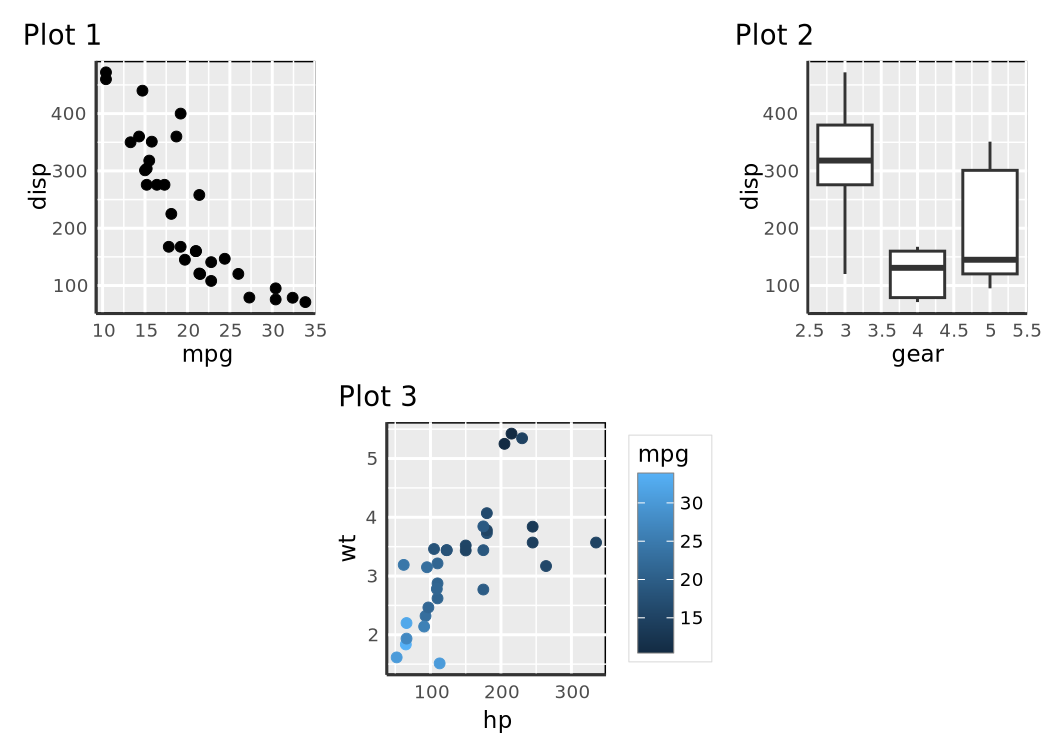

In [2]:
p1 + pw.plot_spacer() + p2 + pw.plot_spacer() + p3 + pw.plot_spacer()

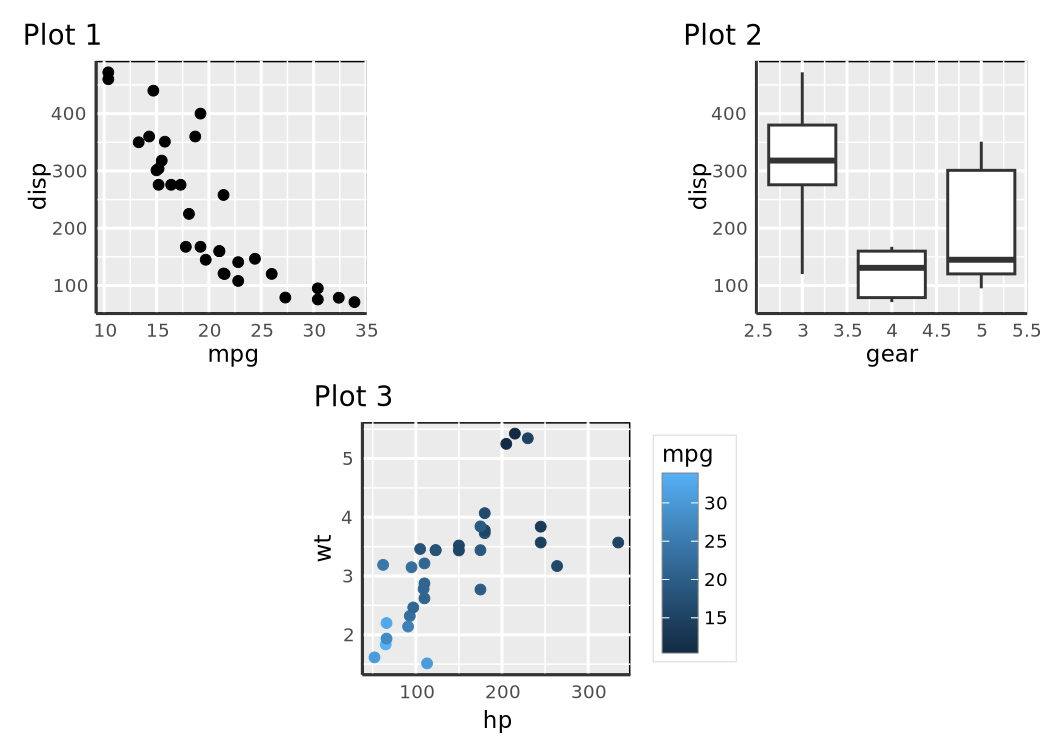

In [3]:
(p1 + pw.plot_spacer() + p2) / (pw.plot_spacer() + p3 + pw.plot_spacer())

## Controlling the grid

`plot_layout()` takes `ncol`, `nrow`, `byrow`, `widths`, `heights`.

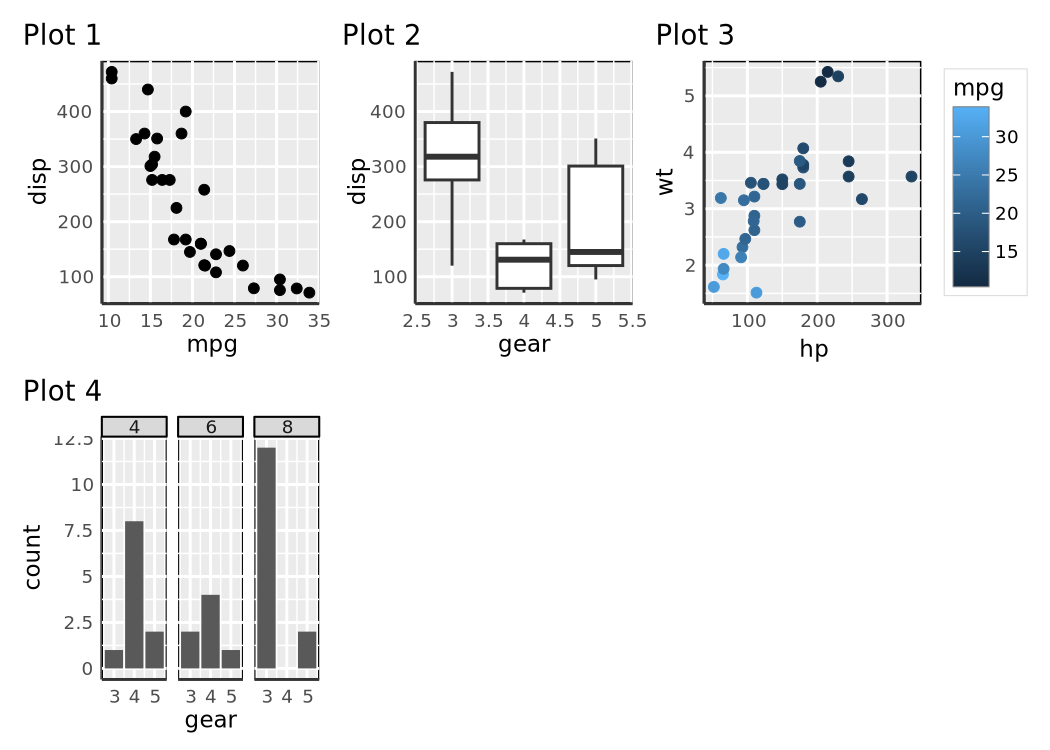

In [4]:
p1 + p2 + p3 + p4 + pw.plot_layout(ncol=3)

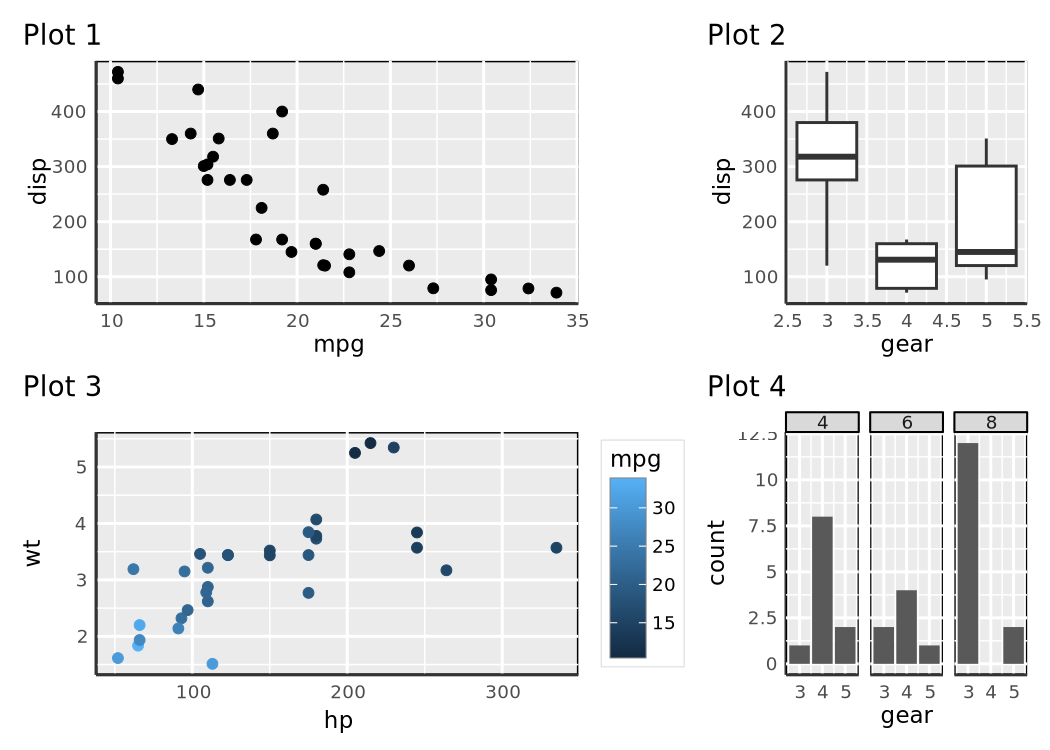

In [5]:
p1 + p2 + p3 + p4 + pw.plot_layout(widths=[2, 1])

Widths and heights can also be explicit grid units:

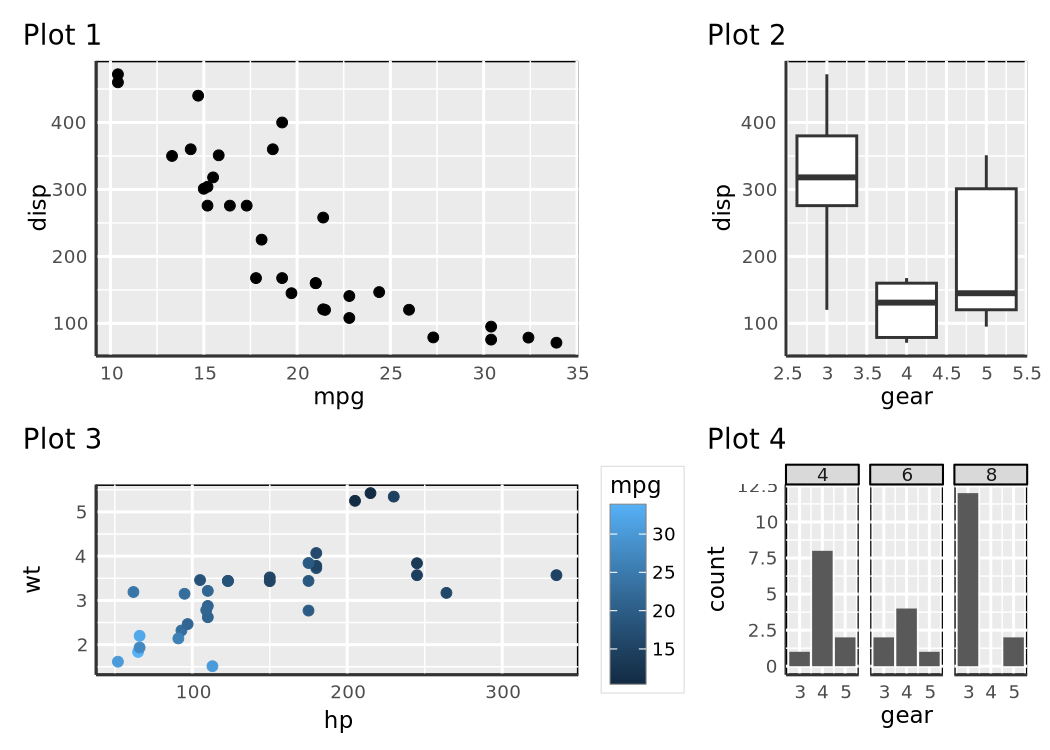

In [6]:
p1 + p2 + p3 + p4 + pw.plot_layout(
    widths=[2, 1],
    heights=Unit([5, 1], ['cm', 'null']),
)

## Moving beyond the grid

A text-form `design` string lets you place plots freely. Use single characters for each plot and `#` for empty cells; patchwork fills plots into areas in alphabetical order:

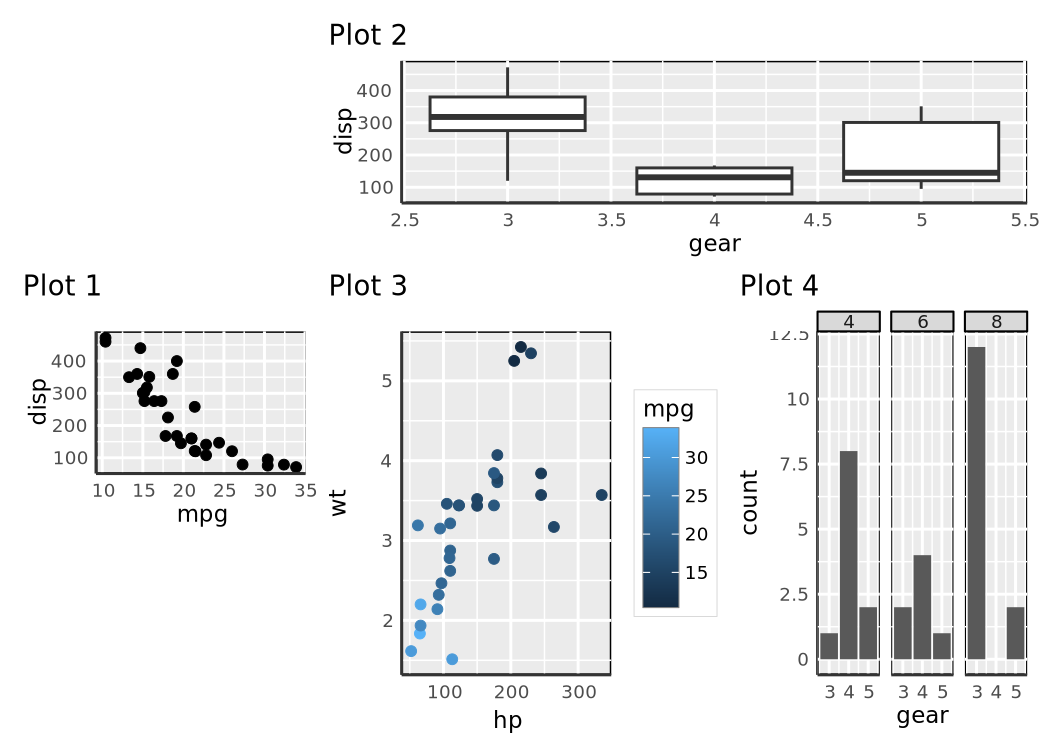

In [7]:
layout = '''
##BBBB
AACCDD
##CCDD
'''
p1 + p2 + p3 + p4 + pw.plot_layout(design=layout)

`area()` gives the same information programmatically and also allows overlapping plots:

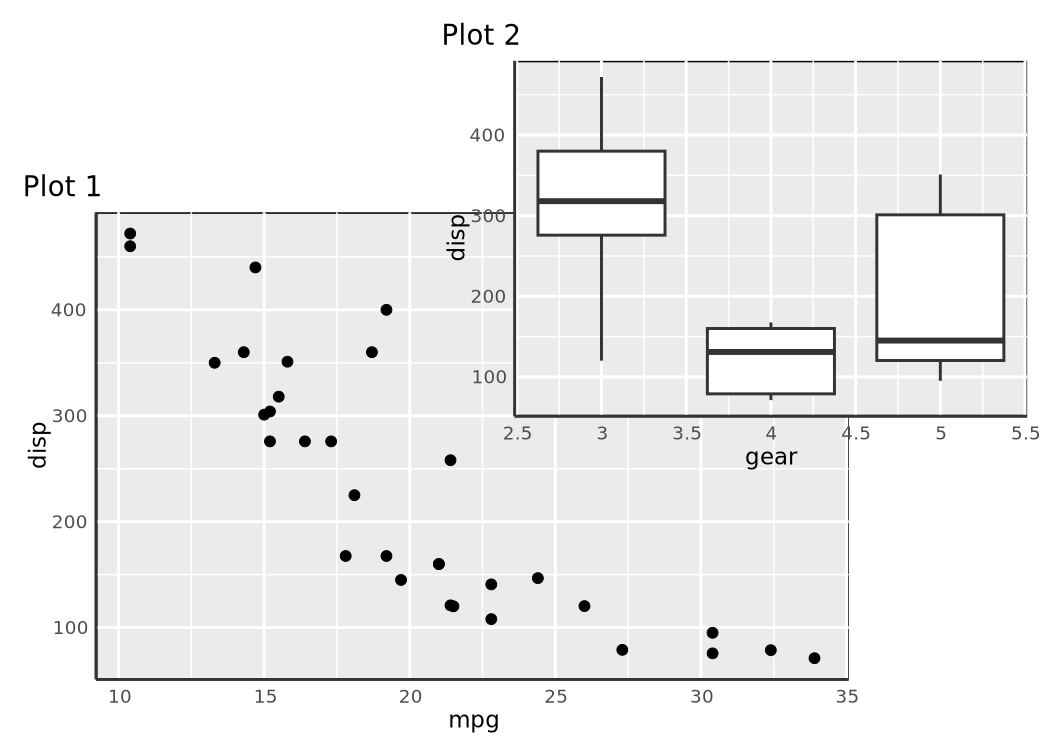

In [8]:
layout = pw.area(t=2, l=1, b=5, r=4) + pw.area(t=1, l=3, b=3, r=5)
p1 + p2 + pw.plot_layout(design=layout)

`wrap_plots()` can match named plots to letter cells in a design string:

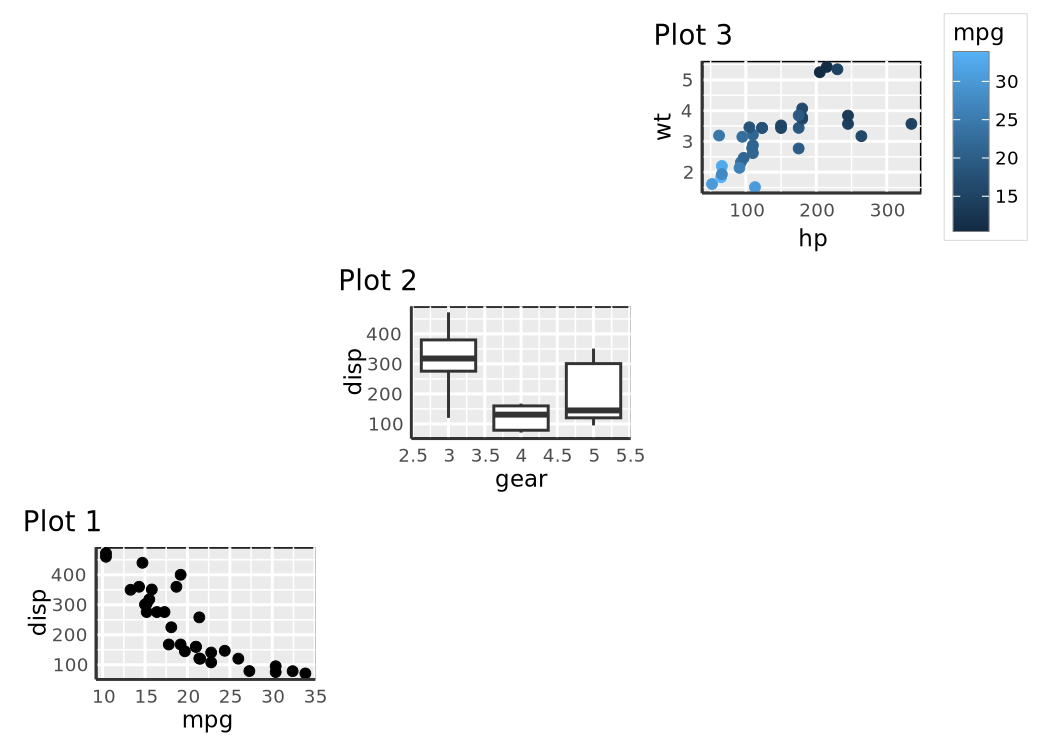

In [9]:
layout = '''
A#B
#C#
D#E
'''
pw.wrap_plots({'D': p1, 'C': p2, 'B': p3}, design=layout)

## Fixed aspect plots

Fixed-aspect plots (e.g. with `coord_fixed()`) behave specially. By default `widths`/`heights` is `NaN`, which acts like `1null` but lets fixed-aspect panels expand or contract to preserve aspect:

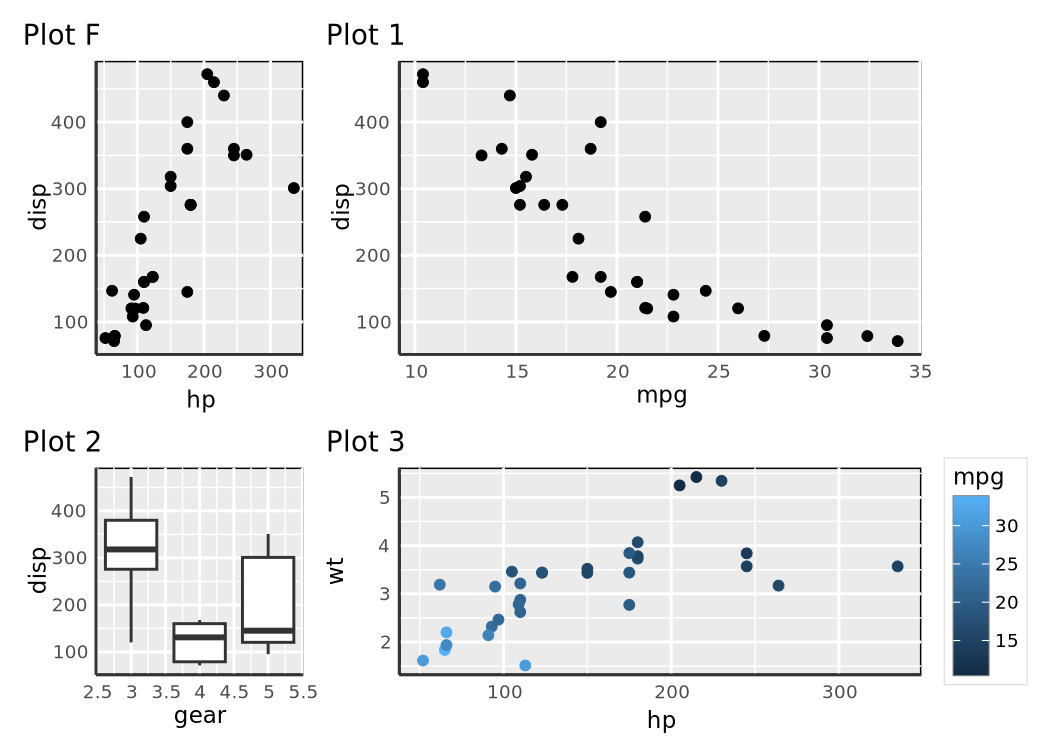

In [10]:
p_fixed = ggplot(df) + geom_point(aes(x='hp', y='disp')) + ggtitle('Plot F') + coord_fixed()
p_fixed + p1 + p2 + p3

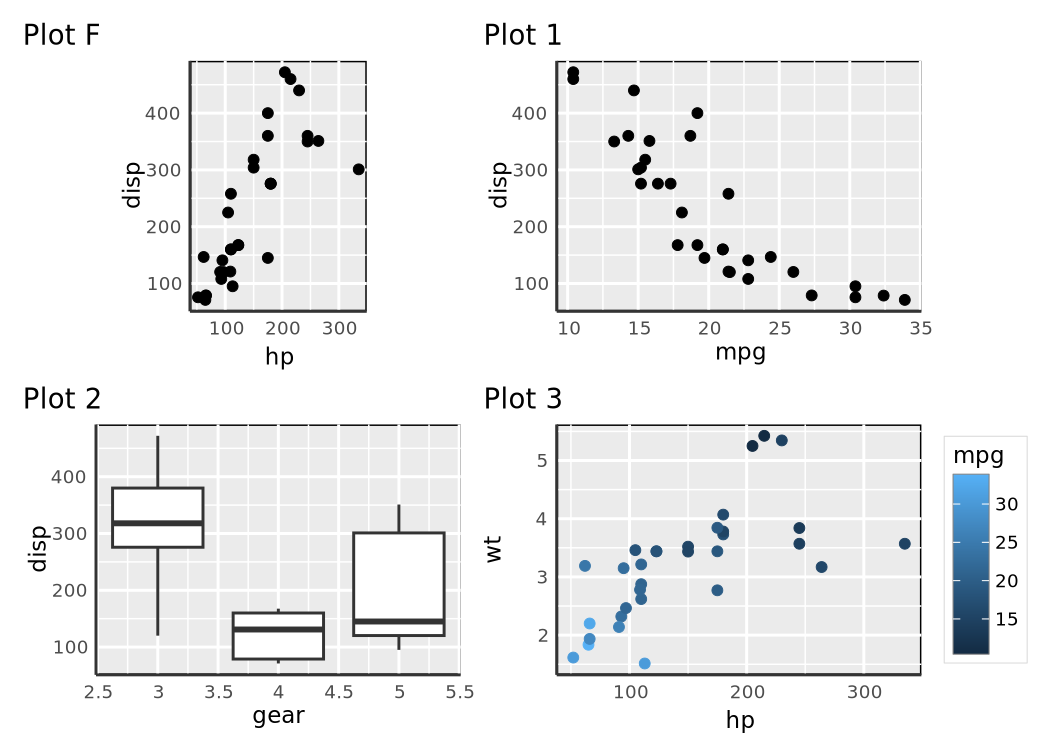

In [11]:
p_fixed + p1 + p2 + p3 + pw.plot_layout(widths=1)

## Avoiding alignment

Long axis labels on one plot can cause unwanted whitespace in siblings. `free()` tells patchwork to leave that plot alone:

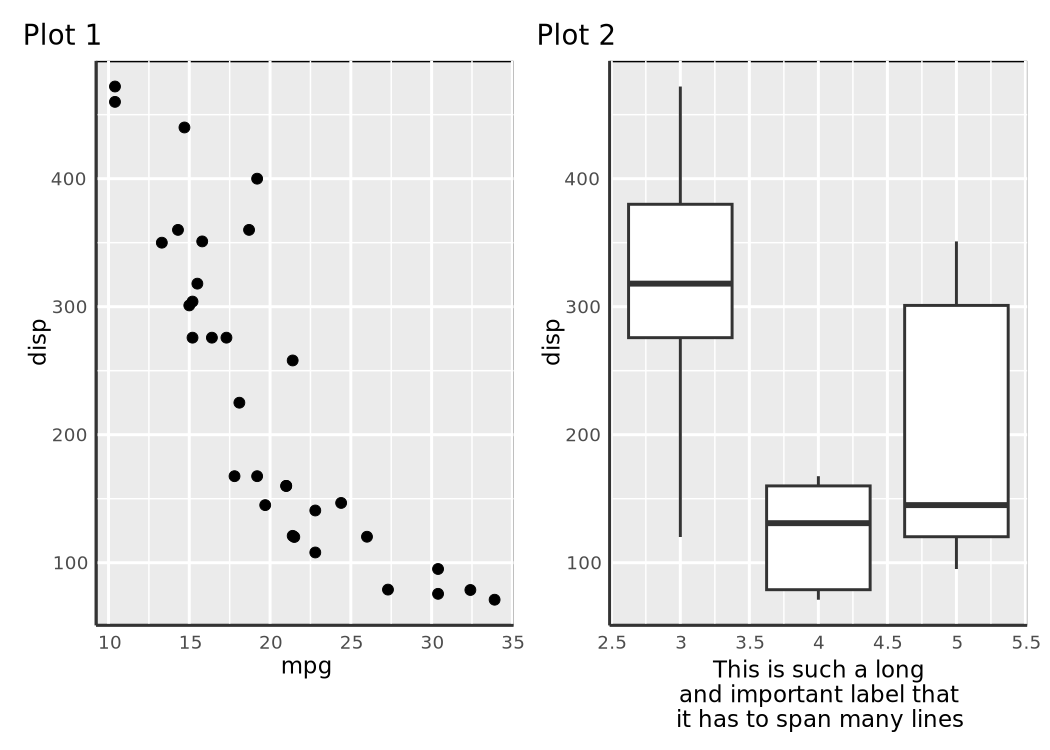

In [12]:
p2mod = p2 + labs(x='This is such a long\nand important label that\nit has to span many lines')
p1 | p2mod

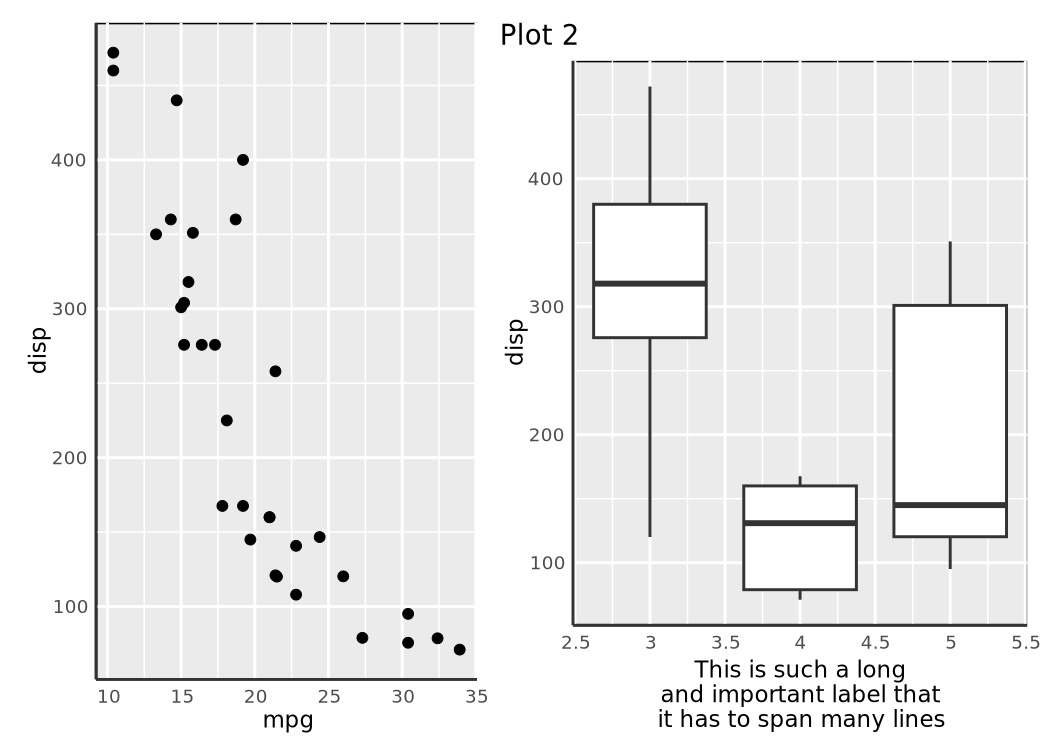

In [13]:
pw.free(p1) | p2mod

`free()` accepts a `side` (subset of `'trbl'`) and a `type` (`'panel'`, `'label'`, `'space'`).

## Insets

`inset_element()` places one plot on top of another without using a grid cell. Numeric coordinates are treated as `npc` (0 to 1 in the relevant area):

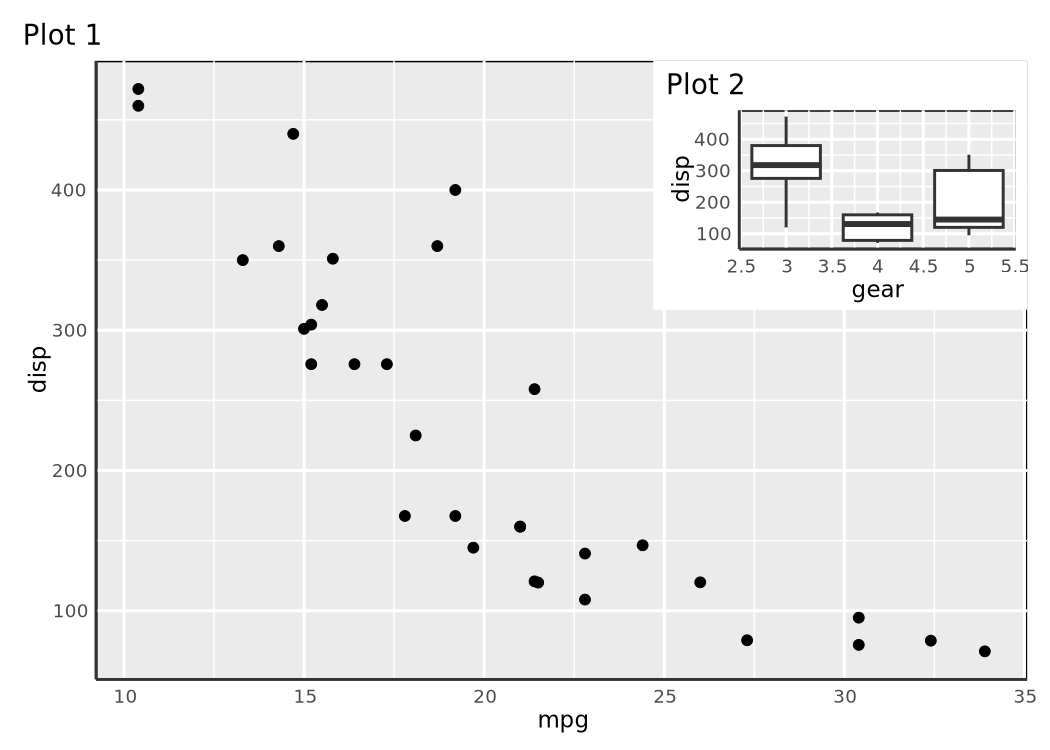

In [14]:
p1 + pw.inset_element(p2, left=0.6, bottom=0.6, right=1, top=1)

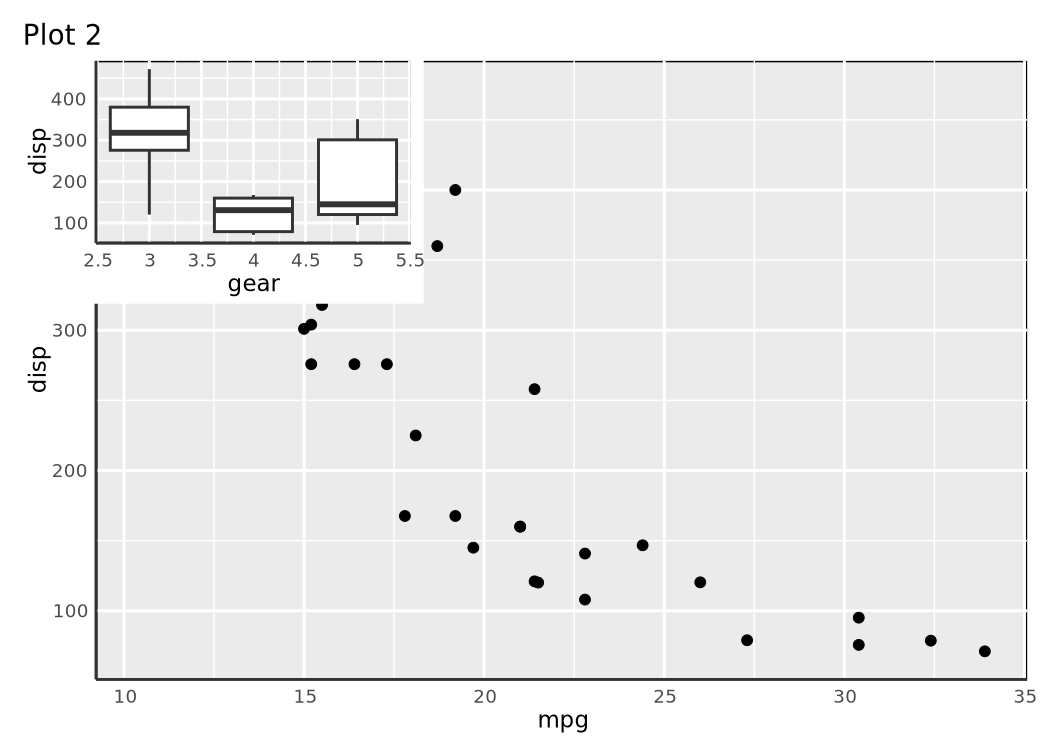

In [15]:
p1 + pw.inset_element(p2, left=0, bottom=0.6, right=0.4, top=1, align_to='full')

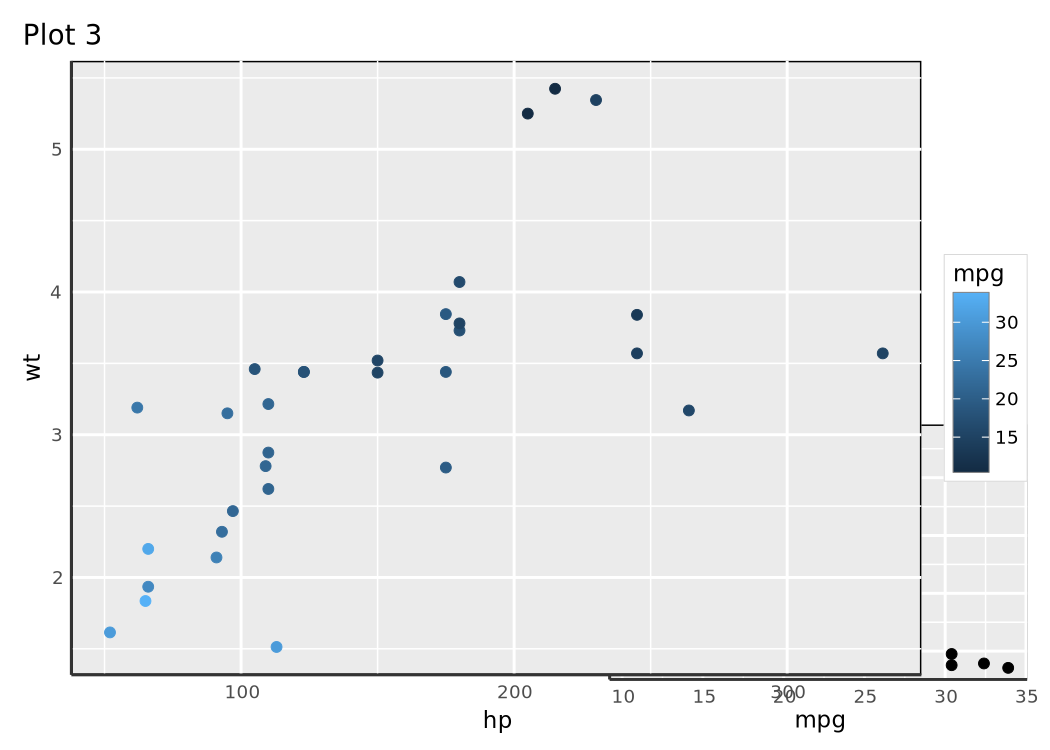

In [16]:
p3 + pw.inset_element(p1, left=0.5, bottom=0, right=1, top=0.5, on_top=False, align_to='full')

## Controlling guides

Set `guides='collect'` to hoist guides from every sub-plot to the outer edge:

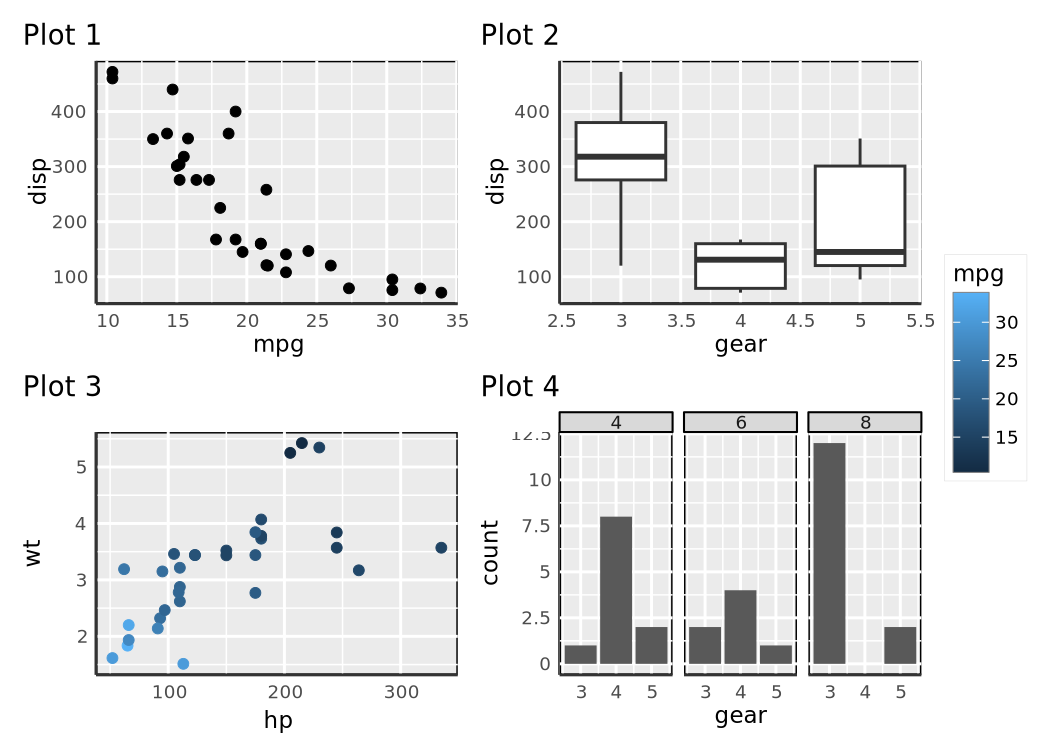

In [17]:
p1 + p2 + p3 + p4 + pw.plot_layout(guides='collect')

Drop a `guide_area()` into the grid to redirect the collected guides there instead of the outer edge:

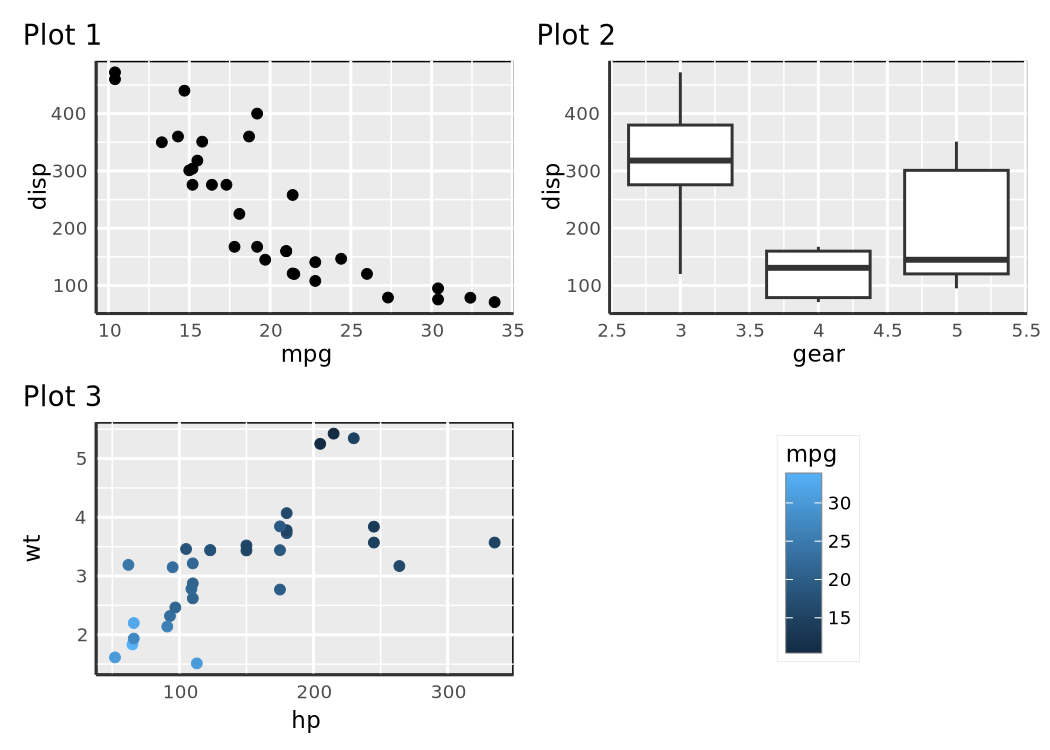

In [18]:
p1 + p2 + p3 + pw.guide_area() + pw.plot_layout(guides='collect')

## Controlling axes

Much like legends, axes can be shared between adjacent plots. `axes='collect'` removes duplicates on a shared row / column; `axis_titles='collect'` keeps the titles centred:

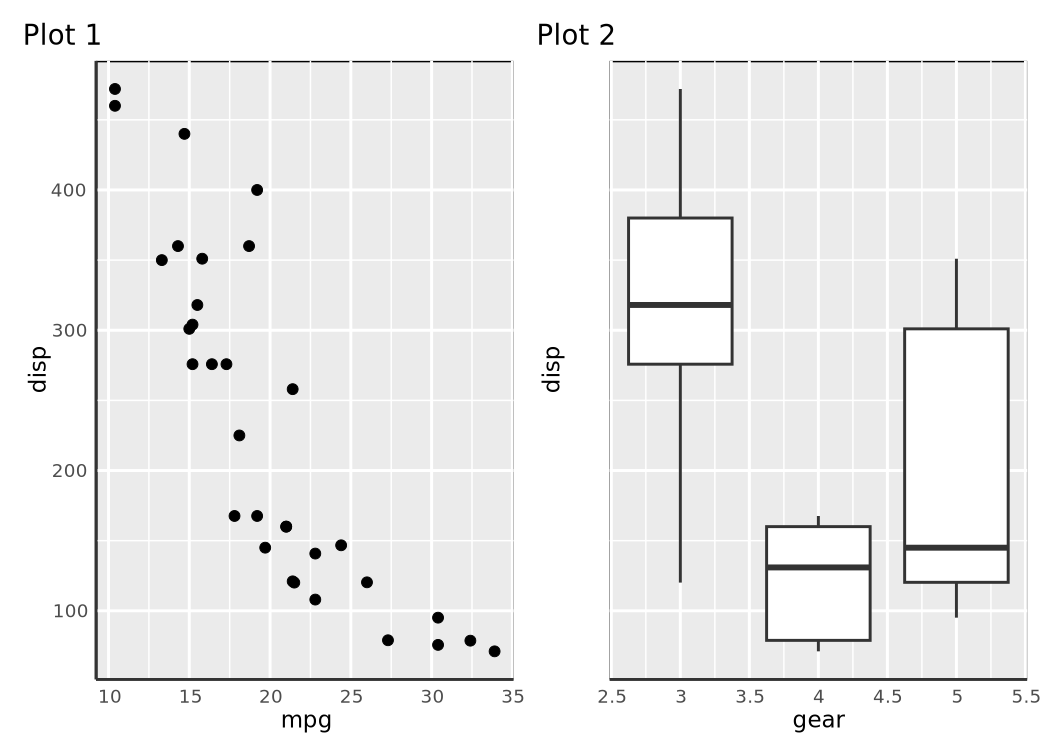

In [19]:
p1 + p2 + pw.plot_layout(axes='collect')

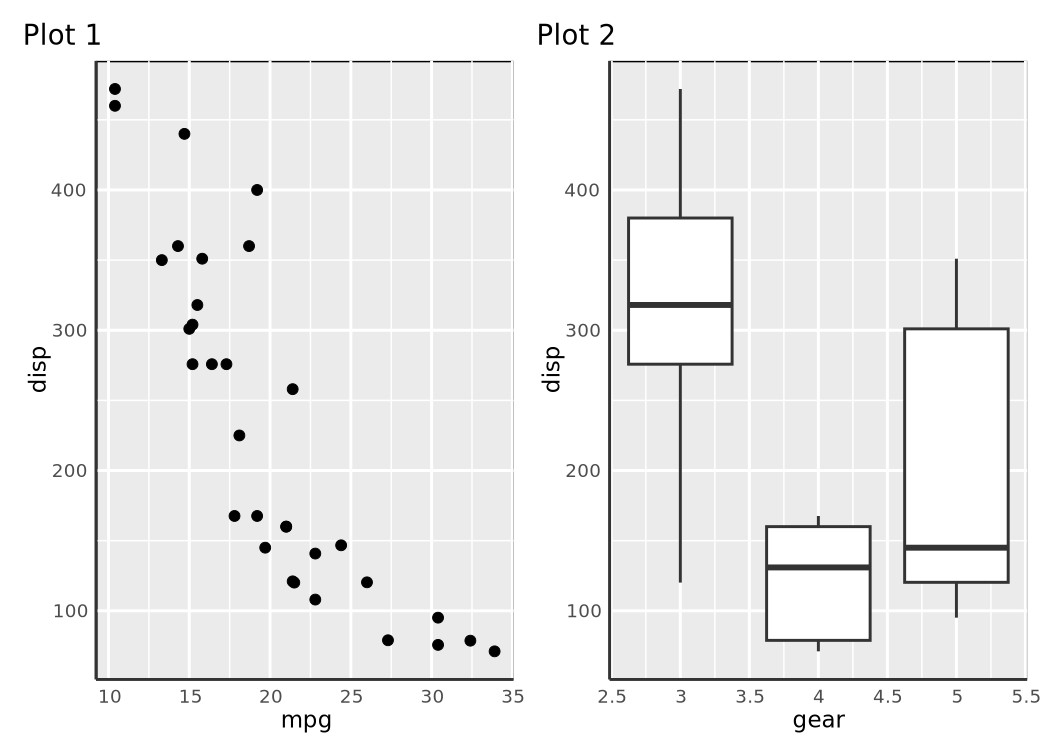

In [20]:
p1 + p2 + pw.plot_layout(axis_titles='collect')

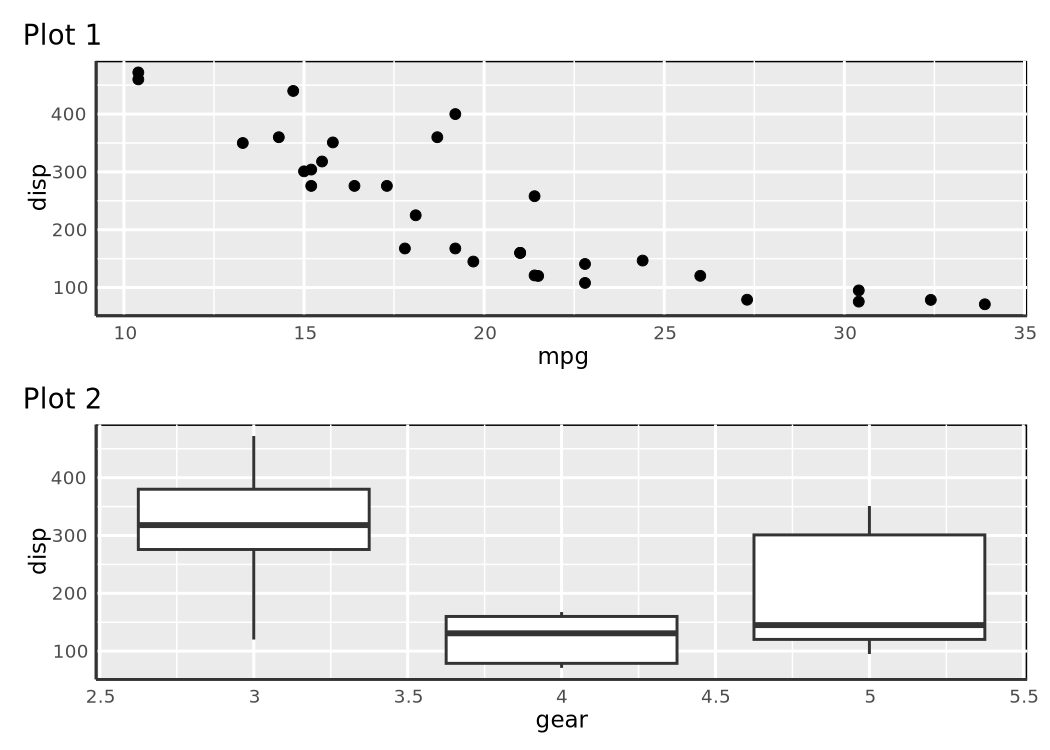

In [21]:
p1 / p2 + pw.plot_layout(axis_titles='collect')